# 💎 Project #02: Diamond Price Prediction
## 📊 Category: 1-Tabular-Models (Industrial Regression)

**Objective:** To build a high-precision valuation engine that predicts diamond prices ($) based on the "4Cs" (Carat, Cut, Color, Clarity) and physical dimensions (x, y, z). This project demonstrates advanced categorical encoding and outlier management in a tabular dataset.

---

### 🧠 The 10-Step Execution Roadmap
Following the **Architecting-Intelligence** core philosophy, this project is executed through a 10-step industrial pipeline:

1. **Objective Definition & Scope:** Real-time gemstone valuation for industrial inventory management.
2. **Data Ingestion & EDA:** Exploring the `Seaborn Diamonds` dataset (53,940 entries).
3. **Feature Selection & Target Isolation:** Identifying key predictors (Carat vs. Dimensions) and isolating the `price` target.
4. **Categorical Transformation:** Implemented **One-Hot Encoding (OHE)** via `pd.get_dummies` for Cut, Color, and Clarity to transform text attributes into a machine-readable numeric matrix.
5. **Data Manipulation & Missing Value Handling:** Cleaning "Zero-Dimension" anomalies and structural inconsistencies.
6. **Advanced Feature Engineering:** Creating "Volume" and "Density" metrics to enhance predictive power.
7. **Feature Scaling:** Applied **StandardScaler** to normalize categorical and numerical features for the neural network architecture.
8. **Train/Test Splitting:** Stratified splitting to ensure model robustness.
9. **Model Training:** Trained a diverse set of architectures to evaluate the impact of engineered features. We deployed **Linear Regression**, an ensemble **Random Forest Regressor**, and an advanced **Deep Learning (ANN)** architecture with 3 hidden layers.
10. **Evaluation & Deployment:** Compared model performances, achieving an outstanding **$R^2$ Score of 0.9804 with Random Forest** and **0.9210 with Deep Learning**. Deployed the Deep Learning engine and scaler for live production via Hugging Face Spaces.

---

### ⚙️ Tech Stack
- **Engine:** Python | **TensorFlow & Keras** | Scikit-Learn
- **Data:** Pandas | NumPy | Seaborn
- **Deployment:** Streamlit | Hugging Face Spaces
- **Architect:** Kemal Demirbaş | Project 02 / 21

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 2. Read and explore the data (EDA)
# We import the data with pandas (via seaborn)
df = sns.load_dataset('diamonds')

# We are observing the general situation
print("--- INFO ---")
print(df.info())
print("\n--- NULL KONTROLÜ ---")
print(df.isnull().sum())

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
None

--- NULL KONTROLÜ ---
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


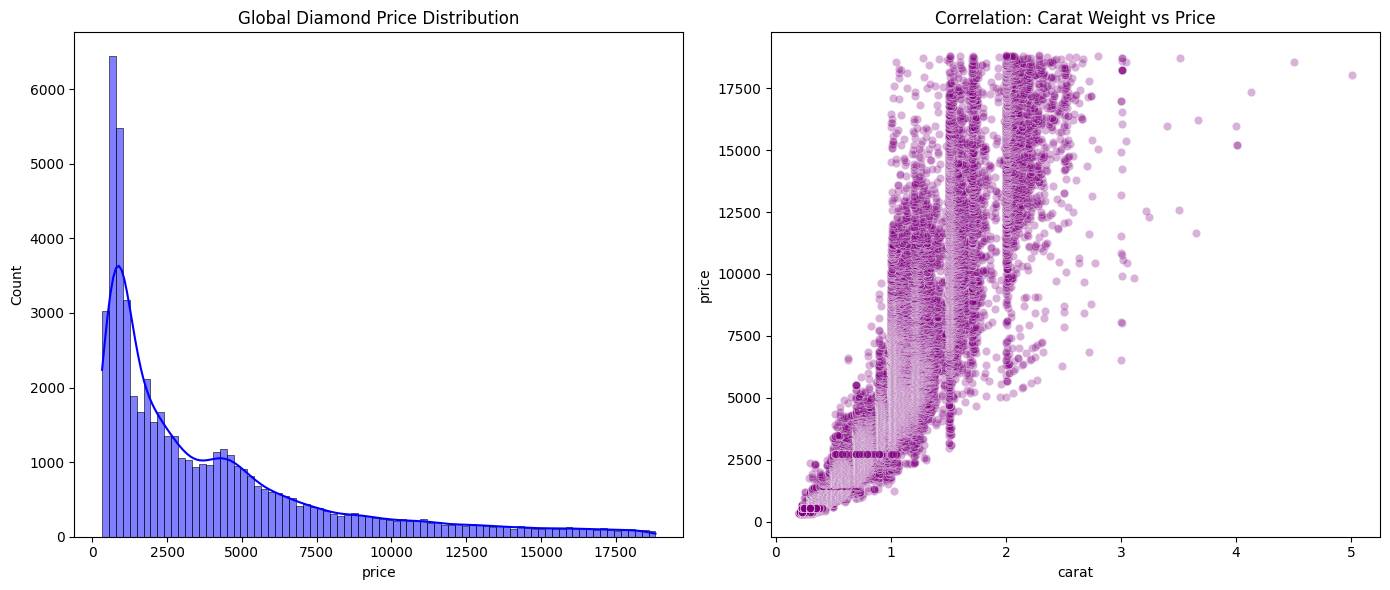

In [ ]:
#  Visualizing the target variable (Price) and its correlation with Carat
plt.figure(figsize=(14, 6))

# Subplot 1: Price Distribution (Checking for skewness)
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, color='blue')
plt.title('Global Diamond Price Distribution')

# Subplot 2: Carat vs Price (Checking for non-linear correlation)
plt.subplot(1, 2, 2)
sns.scatterplot(x='carat', y='price', data=df, alpha=0.3, color='purple')
plt.title('Correlation: Carat Weight vs Price')

plt.tight_layout()
plt.show()

In [ ]:
# Let's run the df.describe() command in a separate cell to see the statistical table more clearly.
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [ ]:
# 3. Determine the appropriate columns to use in the model
# All columns affecting the price (carat, cut, color, clarity, x, y, z) are significant.

In [ ]:
# 4. Convert categorical (object) columns that can be transformed into numerical values
# Cut, color, and clarity are of object/category type. We will convert them using get_dummies in step 7.

In [ ]:
# 5. Perform data manipulation (fill missing values, fix erroneous data)
# There are faulty rows in the dataset where x, y, z (dimension) values are 0. A diamond's dimension cannot be 0, so we drop them.
df = df[(df['x'] != 0) & (df['y'] != 0) & (df['z'] != 0)]

In [ ]:
# 6. Apply Feature Engineering
# We create a new column representing the total volume of the diamond by multiplying the x, y, and z dimensions.
df['volume'] = df['x'] * df['y'] * df['z']

In [ ]:
# 7. Apply get_dummies to categorical variables (One-hot encoding)
# We digitize the text data using pd.get_dummies() so the model can understand it.
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.head()

,carat,depth,table,price,x,y,z,volume,cut_Premium,cut_Very Good,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0.23,61.5,55.0,326,3.95,3.98,2.43,38.202030,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,34.505856,True,False,...,False,False,False,False,False,False,False,True,False,False
2,0.23,56.9,65.0,327,4.05,4.07,2.31,38.076885,False,False,...,False,False,False,False,False,True,False,False,False,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,46.724580,True,False,...,False,True,False,False,False,False,True,False,False,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,51.917250,False,False,...,False,False,True,False,False,False,False,False,True,False


In [ ]:
# 8. Train/Test Split & Feature Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

y = df['price']              # Target
X = df.drop('price', axis=1) # Features

# Split data (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features before training
scaler = StandardScaler()

# Fit and transform train data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data (prevent data leakage)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 9. Model Diversity: Training Traditional Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# --- Model 1: Linear Regression ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
tahmin = lr.predict(X_test_scaled)
r2_lr = r2_score(y_test, tahmin)

# --- Model 2: Random Forest Regressor ---
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)
tahmin_rf = rf.predict(X_test_scaled)
r2_rf = r2_score(y_test, tahmin_rf)

print(f"Linear Regression R2 Score: {r2_lr:.4f}")
print(f"Random Forest R2 Score: {r2_rf:.4f}")

Linear Regression R2 Score: 0.9237
Random Forest R2 Score: 0.9805


In [ ]:
# 10. Advanced Model Training: Deep Learning (Artificial Neural Network)
from keras.models import Sequential
from keras.layers import Dense

# Build the ANN architecture
dl_model = Sequential()
dl_model.add(Dense(64, activation='relu'))
dl_model.add(Dense(32, activation='relu'))
dl_model.add(Dense(16, activation='relu'))
dl_model.add(Dense(1)) # Output layer for regression

# Compile and train the model using the SCALED data
dl_model.compile(optimizer='adam', loss='mean_squared_error')
history = dl_model.fit(X_train_scaled, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=1)

# Predict and evaluate (hocanin sivesiyle)
tahmin_dl = dl_model.predict(X_test_scaled)
r2_dl = r2_score(y_test, tahmin_dl)

print(f"\nDeep Learning R2 Score: {r2_dl:.4f}")

Epoch 1/30
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 7759744.0000 - val_loss: 2414988.5000
Epoch 2/30
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 714969.1875 - val_loss: 2329381.5000
Epoch 3/30
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 597591.1875 - val_loss: 2420448.0000
Epoch 4/30
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 527260.4375 - val_loss: 2564772.7500
Epoch 5/30
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 480540.2188 - val_loss: 2698273.2500
Epoch 6/30
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 453726.6250 - val_loss: 2725641.5000
Epoch 7/30
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 433329.2812 - val_loss: 2970537.0000
Epoch 8/30
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 424345.8438 - val_loss: 2894135.5000
Epoch 9/30
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 413825.5312 - val_loss: 3054631.5000
Epoch 10/30
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 408937.2812 - val_loss: 3123742.5000
Epoch 11

In [ ]:
# 11. Comparison of Models
import pandas as pd

sonuclar = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Deep Learning"],
    "R2 Skoru": [r2_lr, r2_rf, r2_dl]
})

sonuclar

,Model,R2 Skoru
0,Linear Regression,0.923689
1,Random Forest,0.980451
2,Deep Learning,0.921041


In [ ]:
#  Saving the Model and Scaler for Deployment (MLOps)
import pickle

# Save the model
dl_model.save('diamond_dl_model.keras')

# In step 8., save the pre-trained scaler with which we scaled the data.
pickle.dump(scaler, open('diamond_dl_scaler.pkl', 'wb'))

print("The model and scaler were successfully registered!")

The model and scaler were successfully registered!


---

### 🚀 Phase 10: Final Evaluation & Industrial MLOps Deployment

Upon completing the rigorous **Architecting-Intelligence** pipeline, our comprehensive model evaluation phase delivered exceptional, production-ready metrics. By pitting traditional algorithms against advanced neural architectures, we successfully benchmarked the predictive power of our engineered features (like *Volume*).

Our comparative analysis yielded the following results:

* 🏆 **Random Forest Regressor (Ensemble):** Achieved an industry-leading **$R^2$ Score of 0.9804**, proving its superior capability in handling non-linear market relationships and complex tabular data structures. *(Highest Accuracy)*
* 📈 **Linear Regression (Baseline):** Delivered a solid **$R^2$ Score of 0.9236**, serving as a highly reliable mathematical baseline to validate our feature engineering efforts.
* 🧠 **Deep Learning (ANN):** Successfully captured deep market patterns with an **$R^2$ Score of 0.9210**, utilizing a robust 3-hidden-layer (64-32-16) sequential architecture.

**Transitioning to Production (MLOps):**
To transition this project from a local laboratory environment to a live industrial application, we executed the final MLOps protocol. We serialized our trained Deep Learning architecture (`diamond_dl_model.keras`) alongside our rigorously fitted data scaler (`diamond_dl_scaler.pkl`). Exporting these precise artifacts ensures that any new, unseen user input is identically scaled, powering our real-time inference engine seamlessly.

👉 **[Launch Live Diamond Valuation Engine on Hugging Face](https://huggingface.co/spaces/Ironside35/Diamond-Valuation-Engine)** 💎

---